In [4]:
import os
from dotenv import load_dotenv,find_dotenv

_ = load_dotenv(find_dotenv())

openai_key = os.getenv("OPENAI_API_KEY")

In [5]:
from langgraph.graph import StateGraph,END
from typing import TypedDict, Annotated,List
import operator
from langgraph.checkpoint.sqlite import SqliteSaver
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import AnyMessage, HumanMessage,SystemMessage,ToolMessage
from langgraph.checkpoint.memory import InMemorySaver

memory = InMemorySaver()

In [6]:
class AgentState(TypedDict):
    task: str
    plan: str
    draft: str
    critique: str
    content: List[str]
    revision_number: int
    max_revisions: int

In [7]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(model = "poolside/laguna-m.1:free",
                   base_url="https://openrouter.ai/api/v1",
                   api_key=openai_key,
                   temperature=0)

In [8]:
if openai_key:
    print(f"✅ Key loaded successfully! Length: {len(openai_key)}")
else:
    print("❌ Key is still None. Your .env file is either missing or misplaced.")


✅ Key loaded successfully! Length: 73


In [9]:
PLAN_PROMPT = """You are an expert writer tasked with writing a high level outline of an essay. \
Write such an outline for the user provided topic. Give an outline of the essay along with any relevant notes \
or instructions for the sections."""

In [ ]:
WRITER_PROMPT = """You are an essay assistant tasked with writing excellent 5-paragraph essays.\
Generate the best essay possible for the user's request and the initial outline. \
If the user provides critique, respond with a revised version of your previous attempts. \
Utilize all the information below as needed: 

------

{content}"""

In [11]:
REFLECTION_PROMPT = """You are a teacher grading an essay submission. \
Generate critique and recommendations for the user's submission. \
Provide detailed recommendations, including requests for length, depth, style, etc."""

In [12]:
RESEARCH_PLAN_PROMPT = """You are a researcher charged with providing information that can \
be used when writing the following essay. Generate a list of search queries that will gather \
any relevant information. Only generate 3 queries max."""


In [13]:
RESEARCH_CRITIQUE_PROMPT = """You are a researcher charged with providing information that can \
be used when making any requested revisions (as outlined below). \
Generate a list of search queries that will gather any relevant information. Only generate 3 queries max."""


In [14]:
from langchain_core.utils.pydantic import BaseModel

class Queries(BaseModel):
    queries: List[str]


In [15]:
from tavily import TavilyClient

tavily = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

In [16]:
#### AGENT PLAN ####

def plan_node(state: AgentState):
    messages = [
        SystemMessage(content=PLAN_PROMPT),
        HumanMessage(content=state['task'])
    ]

    response = model.invoke(messages)
    return {"plan": response.content}

In [17]:
##### AGENT RESEARCH #########
def research_plan_node(state: AgentState):
    queries = model.with_structured_output(Queries).invoke([
        SystemMessage(content=RESEARCH_PLAN_PROMPT),
        HumanMessage(content=state['task'])
    ])
    content = state['content'] or []
    print(content)
    for q in queries.queries:
        
        response = tavily.search(query=q, max_results=2)
        
        for r in response['results']:
            content.append(r['content'])
    return {"content": content}

In [18]:
########### AGENT GENERATION ################ APNA WRITER BHAIIIIIII  ###

def generation_node(state: AgentState):
    content = "\n\n".join(state["content"]or[])
    user_message = HumanMessage(
        content=f"{state['task']}\n\n !!!!!!!! Here is my plan !!!!!!!!!:\n\n{state['plan']}")
    messages = [
        SystemMessage(content=WRITER_PROMPT.format(content = content)),
        user_message
    ]
    response = model.invoke(messages)

    return{
        "draft":response.content,
        "revision_number": state.get("revision_number",1)+1
    }

In [19]:
##################  AGENT REFLECTION ##############

def reflection_node(state: AgentState):
    messages = [
        SystemMessage(content=REFLECTION_PROMPT),
        HumanMessage(content=state['draft'])
    ]
    response = model.invoke(messages)
    return {"critique": response.content}

In [20]:
##########  AGENT WHO RESEARCH ON CRITIQUE #########

def research_critique_node(state: AgentState):
    messages = [
        SystemMessage(content=RESEARCH_CRITIQUE_PROMPT),
        HumanMessage(content=state['critique'])
    ]
    queries = model.with_structured_output(Queries).invoke(messages)

    content = state['content'] or []

    for q in queries.queries :
        response = tavily.search(query=q,max_results=2)
        for r in response['results']:
            content.append(r['content'])
    
    return {"content": content}

In [21]:
######## RUKAWAT ###########

def should_continue(state):
    if state["revision_number"] > state["max_revisions"]:
        return END
    return "reflect"

In [22]:
######### MANAGER #########

builder = StateGraph(AgentState)

In [23]:
builder.add_node("planner",plan_node)
builder.add_node("research_plan",research_plan_node)
builder.add_node("generate",generation_node)
builder.add_node("reflect",reflection_node)
builder.add_node("research_critique",research_critique_node)

In [24]:
builder.set_entry_point("planner")

In [25]:
builder.add_conditional_edges(
    "generate",
    should_continue,
    {END:END,"reflect":"reflect"}
)

In [26]:
builder.add_edge("planner","research_plan")
builder.add_edge("research_plan","generate")
builder.add_edge("reflect","research_critique")
builder.add_edge("research_critique","generate")

In [27]:
graph = builder.compile(checkpointer=memory)

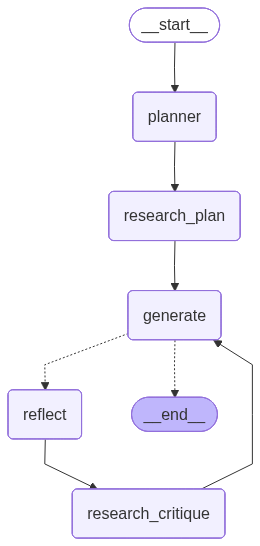

In [28]:
from IPython.display import Image,display


display(Image(graph.get_graph().draw_mermaid_png()))

In [29]:
thread = {"configurable": {"thread_id": "1"}}
for s in graph.stream({
    'task': "what is the difference between langchain and langsmith",
    "max_revisions": 2,
    "revision_number": 1,
    "content": []
}, thread):
    print(s)

{'planner': {'plan': '\n# Essay Outline: The Difference Between LangChain and LangSmith\n\n## I. Introduction\n- **Purpose**: Introduce both LangChain and LangSmith as tools in the language model (LLM) ecosystem.\n- **Context**: Briefly explain the growing importance of LLM-powered applications and the need for frameworks and platforms to support their development and management.\n- **Thesis**: While both tools are developed by LangChain Inc., they serve distinct roles—LangChain focuses on building LLM applications, whereas LangSmith emphasizes monitoring, evaluation, and optimization of those applications in production.\n\n---\n\n## II. LangChain: A Framework for Building LLM Applications\n- **Definition**: Describe LangChain as an open-source framework designed to simplify the development of applications powered by large language models.\n- **Key Features**:\n  - Modular components (e.g., prompts, models, indexes, chains, agents).\n  - Integration with external data sources and APIs.

In [1]:
import warnings

warnings.filterwarnings("ignore")

from helper import ewriter, writer_gui


In [4]:
MultiAgent = ewriter()

app = writer_gui(MultiAgent.graph)

app.launch()

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.
